# First Regression/Classification Model Pipeline

#### Proposed pipeline
`EMG + IMU → preprocessing → bilateral movement-state generation → state classification → bilateral transition validation → accepted motor state`

The data contains:
- 8 EMG channels
- 6 IMUs (left/right thigh, shank, foot)
- each IMU has Accel X/Y/Z and Gyro X/Y/Z
- standing baseline + five-step walking trial

Time/history is used for **state-transition tracking and fault detection**, not future prediction.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

### 1. Load the Data

In [3]:
STANDING_FILE = "../Data/standing still z.xlsx"
WALKING_FILE = "../Data/Walking z 1.xlsx"

standing = pd.read_excel(STANDING_FILE)
walking = pd.read_excel(WALKING_FILE)

print("Standing:", standing.shape)
print("Walking :", walking.shape)
display(walking.head())

Standing: (32624, 45)
Walking : (12360, 45)


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
0,0.0000,-2.1386,0.4033,-17.1598,-3.3709,-5.4275,-0.1902,-2.9087,-3.6227,974.1211,34.5459,-264.8926,-17.4844,-0.7046,11.1875,1003.9,-157.7148,-210.8154,-24.3281,-11.7109,0.7275,292.4805,518.0664,804.1992,28.5156,-6.9961,-13.9062,909.1797,-361.8164,-192.6270,-3.1660,22.4062,4.4492,976.5625,119.9951,-235.4736,-18.3438,4.5195,-11.9219,-281.9824,414.5508,878.9062,22.4844,1.6807,-1.5576
1,0.0005,0.3029,-4.4798,-20.5170,-5.2020,-6.0378,-1.1058,-0.4672,-8.8110,973.2422,33.2626,-263.3545,-17.4312,-0.5538,11.0125,1004.4,-157.5073,-209.6069,-24.0219,-11.7094,0.8296,290.9424,517.7246,805.1270,28.2375,-6.9844,-13.8141,909.2285,-362.4268,-192.0654,-3.2521,22.3188,4.4898,976.0742,118.7500,-234.1309,-18.3078,4.4965,-11.9438,-283.6670,414.6729,880.0781,22.6969,1.7061,-1.5552
2,0.0010,2.1341,-10.5837,-22.6533,-6.7280,-5.4275,-2.0214,2.5848,-9.4214,972.3633,31.9794,-261.8164,-17.3781,-0.4029,10.8375,1004.9,-157.2998,-208.3984,-23.7156,-11.7078,0.9316,289.4043,517.3828,806.0547,27.9594,-6.9727,-13.7219,909.2773,-363.0371,-191.5039,-3.3383,22.2313,4.5305,975.5859,117.5049,-232.7881,-18.2719,4.4734,-11.9656,-285.3516,414.7949,881.2500,22.9094,1.7314,-1.5527
3,0.0015,4.2704,-17.2980,-22.6533,-5.8124,-3.5963,-2.3266,4.1107,-8.2006,971.4844,30.6961,-260.2783,-17.3250,-0.2521,10.6625,1005.4,-157.0923,-207.1899,-23.4094,-11.7062,1.0337,287.8662,517.0410,806.9824,27.6812,-6.9609,-13.6297,909.3262,-363.6475,-190.9424,-3.4244,22.1437,4.5711,975.0977,116.2598,-231.4453,-18.2359,4.4504,-11.9875,-287.0361,414.9170,882.4219,23.1219,1.7568,-1.5503
4,0.0020,7.3224,-22.7915,-21.7377,-5.5072,-0.2392,-2.3266,3.5004,-8.2006,970.6055,29.4128,-258.7402,-17.2719,-0.1013,10.4875,1005.9,-156.8848,-205.9814,-23.1031,-11.7047,1.1357,286.3281,516.6992,807.9102,27.4031,-6.9492,-13.5375,909.3750,-364.2578,-190.3809,-3.5105,22.0562,4.6117,974.6094,115.0146,-230.1025,-18.2000,4.4273,-12.0094,-288.7207,415.0391,883.5938,23.3344,1.7822,-1.5479


### 2. Group the Signals from the Dataset

In [4]:
time_col = 'Time_s'
emg_cols = list(walking.columns[1:9])
imu_cols = [c for c in walking.columns if c not in [time_col] + emg_cols]
left_cols = [c for c in imu_cols if '_L_' in c]
right_cols = [c for c in imu_cols if '_R_' in c]

print(f"EMG channels: {len(emg_cols)}")
print(f"IMU columns : {len(imu_cols)}")
print(f"Left IMU    : {len(left_cols)}")
print(f"Right IMU   : {len(right_cols)}")
print("EMG:", emg_cols)

EMG channels: 8
IMU columns : 36
Left IMU    : 18
Right IMU   : 18
EMG: ['Multifidus_R', 'Multifidus_L', 'ExternalOblique_R', 'ExternalOblique_L', 'RectusAbdominis_R', 'RectusAbdominis_L', 'ErectorSpinae_R', 'ErectorSpinae_L']


### 3. Validate the Data points

In [5]:
def quality_report(df, name):
    dt = df[time_col].diff().dropna()
    print(f"--- {name} ---")
    print("Rows / columns:", df.shape)
    print("Missing cells:", int(df.isna().sum().sum()))
    print("Duplicate rows:", int(df.duplicated().sum()))
    print("Median sampling interval:", dt.median())
    print("Approx. sampling frequency:", 1 / dt.median(), "Hz")
    display(df.info())
    print()

quality_report(standing, "Standing baseline")
quality_report(walking, "Walking")



--- Standing baseline ---
Rows / columns: (32624, 45)
Missing cells: 468
Duplicate rows: 0
Median sampling interval: 0.000500000000000056
Approx. sampling frequency: 1999.9999999997763 Hz
<class 'pandas.DataFrame'>
RangeIndex: 32624 entries, 0 to 32623
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time_s             32624 non-null  float64
 1   Multifidus_R       32624 non-null  float64
 2   Multifidus_L       32624 non-null  float64
 3   ExternalOblique_R  32624 non-null  float64
 4   ExternalOblique_L  32624 non-null  float64
 5   RectusAbdominis_R  32624 non-null  float64
 6   RectusAbdominis_L  32624 non-null  float64
 7   ErectorSpinae_R    32624 non-null  float64
 8   ErectorSpinae_L    32624 non-null  float64
 9   Thigh_L_Accel_X    32611 non-null  float64
 10  Thigh_L_Accel_Y    32611 non-null  float64
 11  Thigh_L_Accel_Z    32611 non-null  float64
 12  Thigh_L_Gyro_X     32611 non-null  fl

None


--- Walking ---
Rows / columns: (12360, 45)
Missing cells: 1500
Duplicate rows: 0
Median sampling interval: 0.0004999999999999449
Approx. sampling frequency: 2000.0000000002203 Hz
<class 'pandas.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time_s             12360 non-null  float64
 1   Multifidus_R       12360 non-null  float64
 2   Multifidus_L       12360 non-null  float64
 3   ExternalOblique_R  12360 non-null  float64
 4   ExternalOblique_L  12360 non-null  float64
 5   RectusAbdominis_R  12360 non-null  float64
 6   RectusAbdominis_L  12360 non-null  float64
 7   ErectorSpinae_R    12360 non-null  float64
 8   ErectorSpinae_L    12360 non-null  float64
 9   Thigh_L_Accel_X    12351 non-null  float64
 10  Thigh_L_Accel_Y    12351 non-null  float64
 11  Thigh_L_Accel_Z    12351 non-null  float64
 12  Thigh_L_Gyro_X     12351 non-null  float64
 

None

In [6]:
# Check which rows contain missing IMU data
standing_missing_rows = standing.index[standing[imu_cols].isna().any(axis=1)]

walking_missing_rows = walking.index[walking[imu_cols].isna().any(axis=1)]

print("Standing rows with missing IMU data:")
print(standing_missing_rows.tolist())

print("\nWalking rows with missing IMU data:")
print(walking_missing_rows.tolist())

Standing rows with missing IMU data:
[32611, 32612, 32613, 32614, 32615, 32616, 32617, 32618, 32619, 32620, 32621, 32622, 32623]

Walking rows with missing IMU data:
[871, 872, 873, 874, 875, 876, 877, 878, 879, 880, 881, 882, 883, 884, 885, 886, 887, 888, 889, 890, 891, 892, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1431, 143

In [7]:
# Handle Missing IMU Data

# 1. Remove incomplete rows at the END of each recording
standing = standing.dropna(subset=imu_cols, how='all').reset_index(drop=True)
walking = walking.dropna(subset=imu_cols, how='all').reset_index(drop=True)

# 2. Interpolate short internal IMU gaps
walking[imu_cols] = walking[imu_cols].interpolate(
    method='linear',
    limit_area='inside'
)

# 3. Verify
print("Standing missing IMU values:", standing[imu_cols].isna().sum().sum())
print("Walking missing IMU values:", walking[imu_cols].isna().sum().sum())

Standing missing IMU values: 0
Walking missing IMU values: 0


### 4. Visualize EMG: standing vs walking

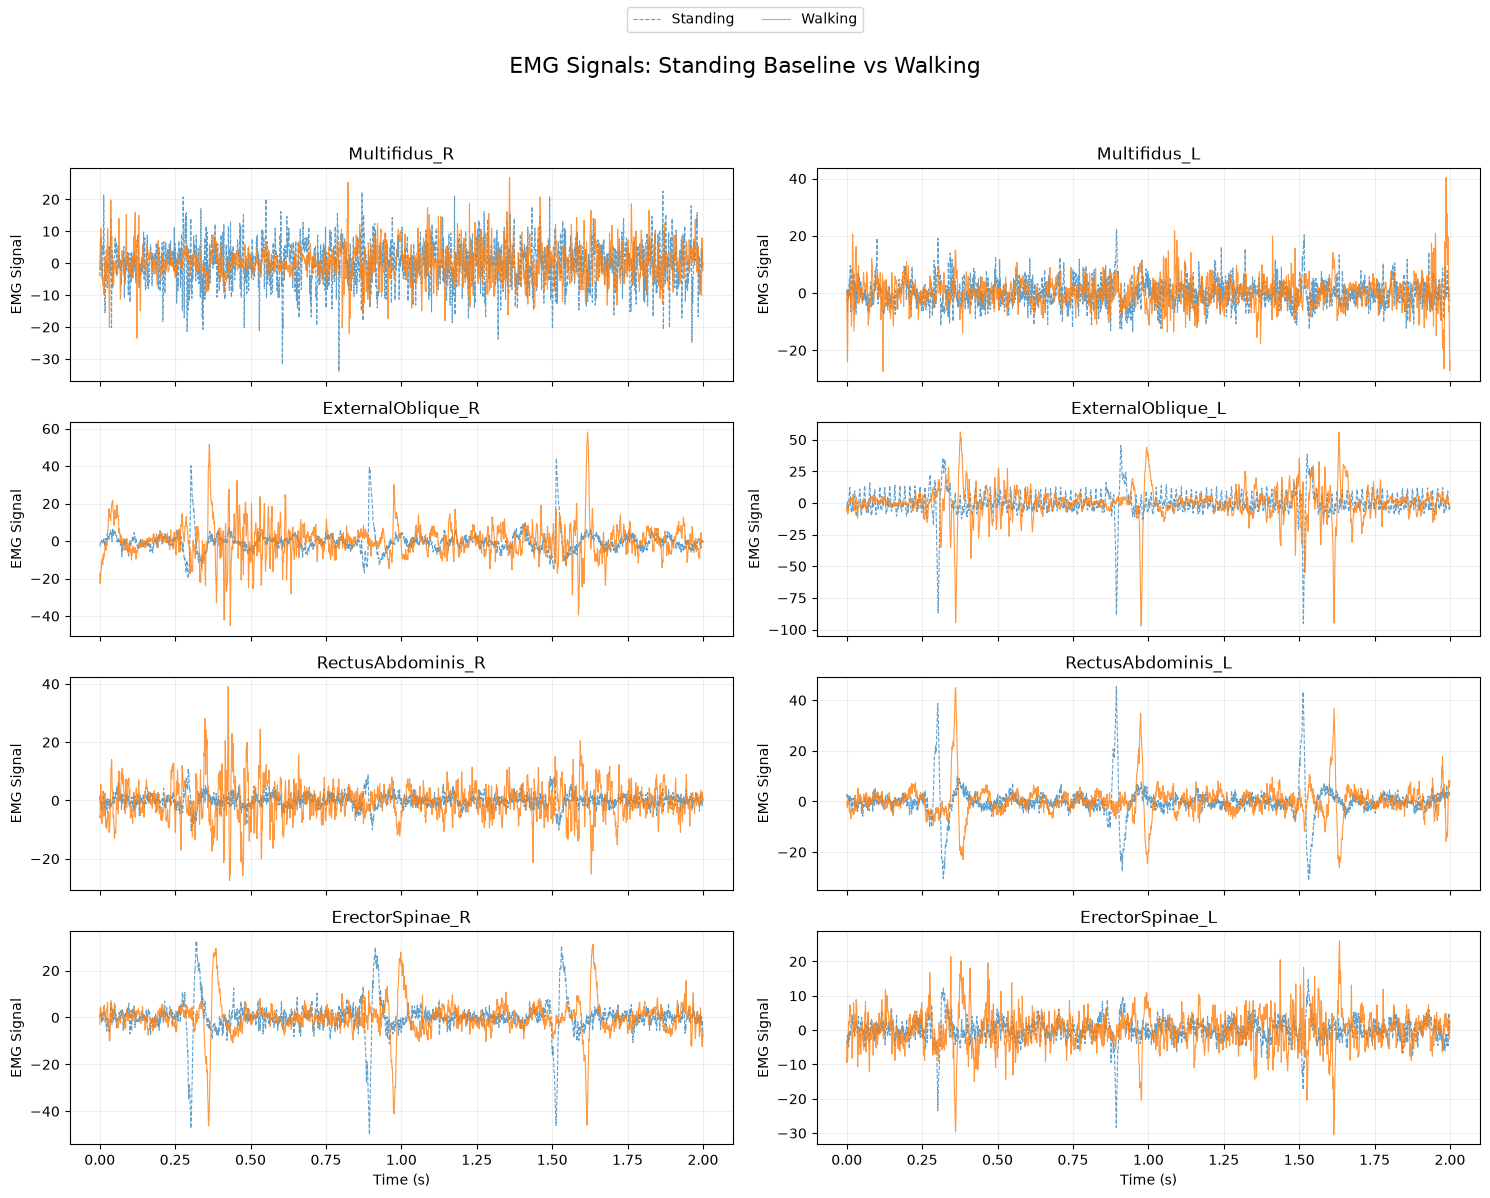

In [8]:
def compare_emg_channels(standing, walking, cols, seconds=2.0):
    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(15, 12),
        sharex=True
    )
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        stand_part = standing[standing[time_col] <= standing[time_col].iloc[0] + seconds]
        walk_part = walking[walking[time_col] <= walking[time_col].iloc[0] + seconds]

        # Shift time so both start at 0
        stand_time = stand_part[time_col] - stand_part[time_col].iloc[0]
        walk_time = walk_part[time_col] - walk_part[time_col].iloc[0]

        # Plot both conditions
        ax.plot(
            stand_time,
            stand_part[col],
            label="Standing",
            linewidth=0.8,
            linestyle="--",
            alpha=0.7
        )
        ax.plot(
            walk_time,
            walk_part[col],
            label="Walking",
            linewidth=0.8,
            linestyle="-",
            alpha=0.8
        )
        ax.set_title(col)
        ax.set_ylabel("EMG Signal")
        ax.grid(alpha=0.2)

    # X label only needed at bottom
    for ax in axes[-2:]:
        ax.set_xlabel("Time (s)")

    # One shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2
    )
    fig.suptitle(
        "\nEMG Signals: Standing Baseline vs Walking",
        fontsize=16,
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

compare_emg_channels(
    standing,
    walking,
    emg_cols,
    seconds=2.0
)

### 5. Visualize IMU: bilateral thigh/shank/foot motion

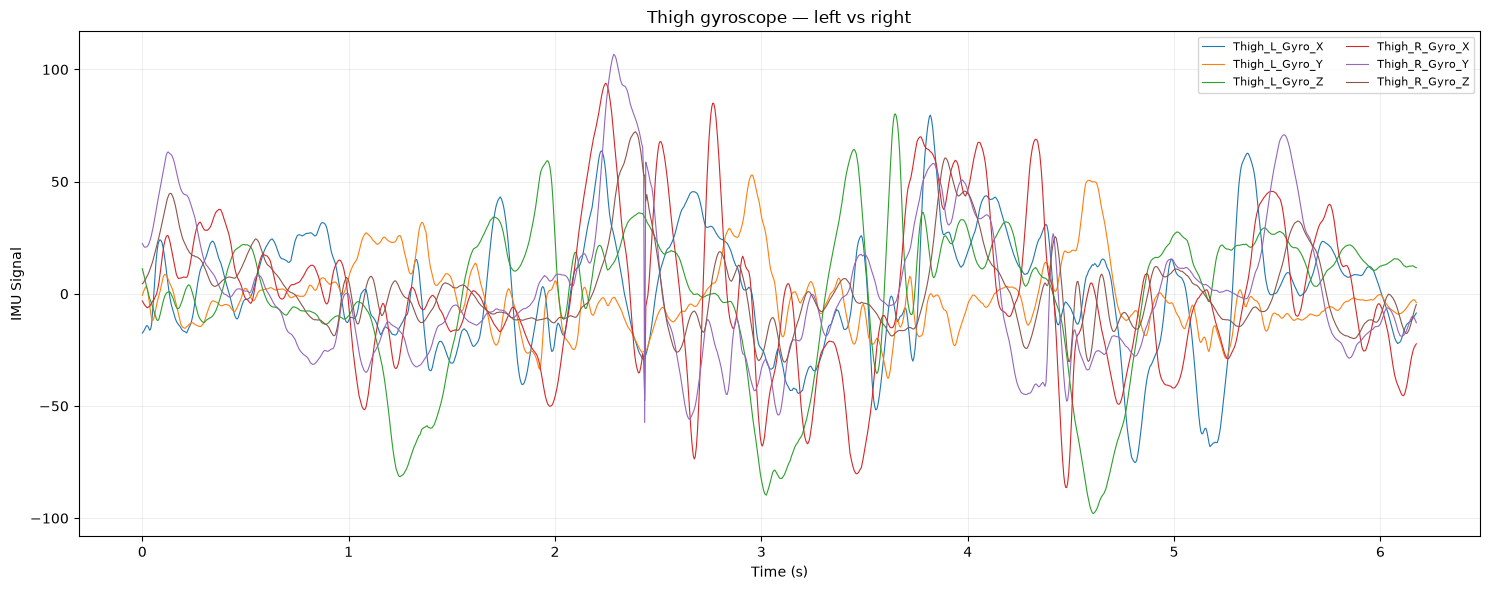

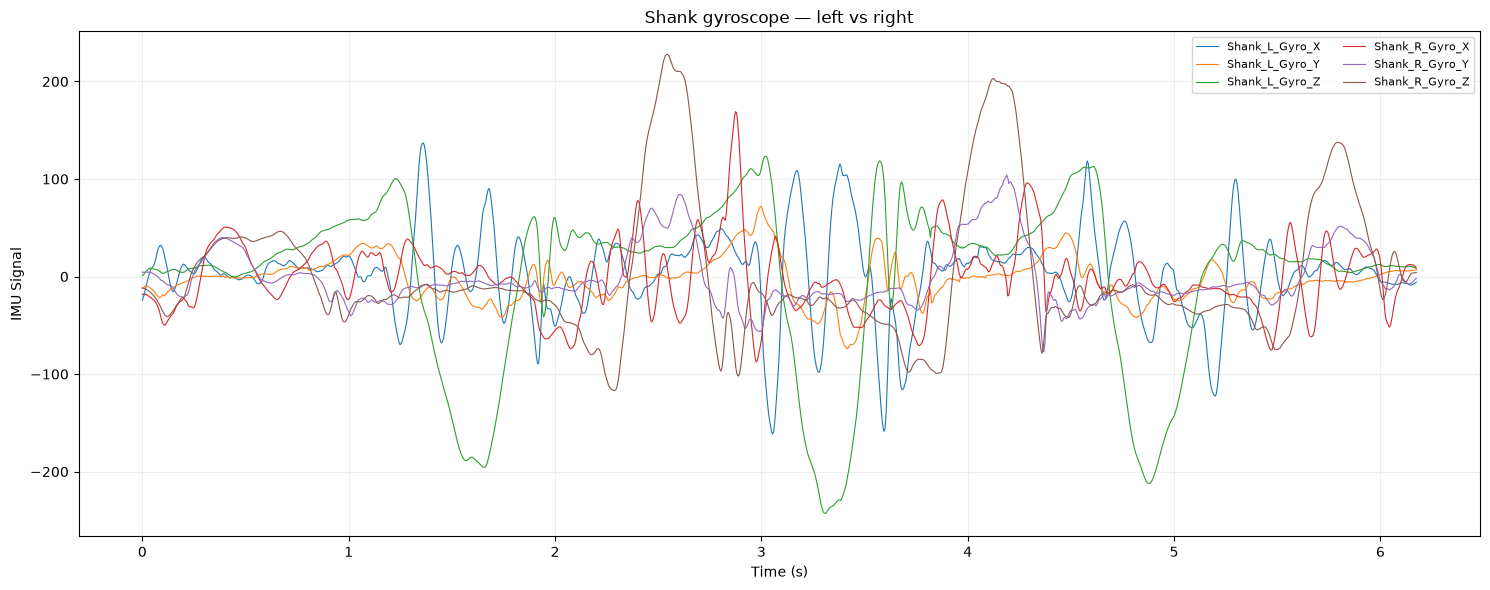

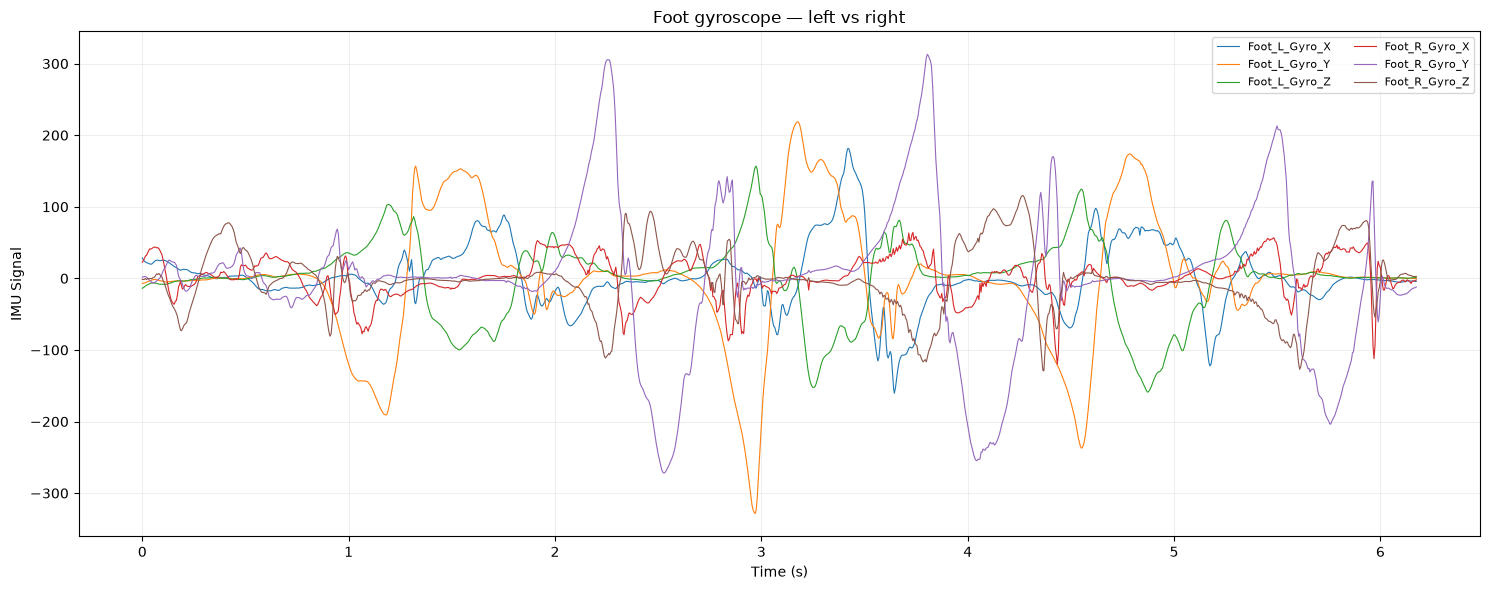

In [9]:
def plot_channels(df, cols, title, seconds=2.0):
    part = df[
        df[time_col] <= df[time_col].iloc[0] + seconds
    ]
    plt.figure(figsize=(15, 6))
    for col in cols:
        plt.plot(
            part[time_col],
            part[col],
            label=col,
            linewidth=0.8
        )
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("IMU Signal")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

for segment in ['Thigh', 'Shank', 'Foot']:
    cols = [f'{segment}_L_Gyro_X', f'{segment}_L_Gyro_Y', f'{segment}_L_Gyro_Z',
            f'{segment}_R_Gyro_X', f'{segment}_R_Gyro_Y', f'{segment}_R_Gyro_Z']
    plot_channels(walking, cols, f"{segment} gyroscope — left vs right", seconds=walking[time_col].iloc[-1])

### 6. Baseline normalization

In [10]:
signal_cols = emg_cols + imu_cols
baseline_mean = standing[signal_cols].mean()
walking_zeroed = walking.copy()
walking_zeroed[signal_cols] = walking[signal_cols] - baseline_mean

display(walking_zeroed.head())

,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
0,0.0000,-2.119702,0.493136,-16.795966,-3.398468,-5.425241,-0.164534,-2.906404,-3.675481,-4.499817,4.829378,-63.398861,-17.436814,-0.773581,11.222772,28.061992,58.277646,-198.067421,-24.339465,-11.755216,0.736252,27.192136,115.247796,-70.121188,28.517314,-6.970278,-13.929625,-24.740325,-59.833176,-2.467422,-3.223716,22.641446,4.476683,42.584209,-142.8835,5.495379,-18.402377,4.469684,-12.011871,23.615108,-6.318747,27.486886,22.488097,1.663733,-1.576191
1,0.0005,0.321798,-4.389964,-20.153166,-5.229568,-6.035541,-1.080134,-0.464904,-8.863781,-5.378717,3.546078,-61.860761,-17.383614,-0.622781,11.047772,28.561992,58.485146,-196.858921,-24.033265,-11.753716,0.838352,25.654036,114.905996,-69.193388,28.239214,-6.958578,-13.837525,-24.691525,-60.443576,-1.905822,-3.309816,22.554046,4.517283,42.095909,-144.1286,6.838079,-18.366377,4.446684,-12.033771,21.930508,-6.196647,28.658786,22.700597,1.689133,-1.573791
2,0.0010,2.152998,-10.493864,-22.289466,-6.755568,-5.425241,-1.995734,2.587096,-9.474181,-6.257617,2.262878,-60.322661,-17.330514,-0.471881,10.872772,29.061992,58.692646,-195.650421,-23.726965,-11.752116,0.940352,24.115936,114.564196,-68.265688,27.961114,-6.946878,-13.745325,-24.642725,-61.053876,-1.344322,-3.396016,22.466546,4.557983,41.607609,-145.3737,8.180879,-18.330477,4.423584,-12.055571,20.245908,-6.074647,29.830686,22.913097,1.714433,-1.571291
3,0.0015,4.289298,-17.208164,-22.289466,-5.839968,-3.594041,-2.300934,4.112996,-8.253381,-7.136517,0.979578,-58.784561,-17.277414,-0.321081,10.697772,29.561992,58.900146,-194.441921,-23.420765,-11.750516,1.042452,22.577836,114.222396,-67.337988,27.682914,-6.935078,-13.653125,-24.593825,-61.664276,-0.782822,-3.482116,22.378946,4.598583,41.119409,-146.6188,9.523679,-18.294477,4.400584,-12.077471,18.561408,-5.952547,31.002586,23.125597,1.739833,-1.568891
4,0.0020,7.341298,-22.701664,-21.373866,-5.534768,-0.236941,-2.300934,3.502696,-8.253381,-8.015417,-0.303722,-57.246461,-17.224314,-0.170281,10.522772,30.061992,59.107646,-193.233421,-23.114465,-11.749016,1.144452,21.039736,113.880596,-66.410188,27.404814,-6.923378,-13.560925,-24.545025,-62.274576,-0.221322,-3.568216,22.291446,4.639183,40.631109,-147.8640,10.866479,-18.258577,4.377484,-12.099371,16.876808,-5.830447,32.174486,23.338097,1.765233,-1.566491


### 7. Generate Bilateral Movement Scores

create labels: Left movement score  0–1 & Right movement score 0–1

In [11]:
# Estimate thigh/sensor orientation from the IMU
def accel_tilt_deg(df, side):
    x = df[f'Thigh_{side}_Accel_X'].to_numpy() # get the position
    y = df[f'Thigh_{side}_Accel_Y'].to_numpy()
    z = df[f'Thigh_{side}_Accel_Z'].to_numpy()
    tilt = np.degrees(np.arctan2(np.sqrt(x**2 + y**2), z))  # calculate the degree
    return tilt

In [12]:
# Determine what is the neutral standing position
standing_tilt_L = accel_tilt_deg(standing, 'L')
standing_tilt_R = accel_tilt_deg(standing, 'R')

neutral_L = np.nanmedian(standing_tilt_L) # use median as the neautral reference
neutral_R = np.nanmedian(standing_tilt_R)

print(f"Left neutral orientation:  {neutral_L:.2f}°")
print(f"Right neutral orientation: {neutral_R:.2f}°")

Left neutral orientation:  101.63°
Right neutral orientation: 101.06°


In [13]:
# Measure movement away from neutral
# Create working copy of walking data
walking_work = walking.copy()

# Calculate thigh orientation during walking
walking_tilt_L = accel_tilt_deg(walking, 'L')
walking_tilt_R = accel_tilt_deg(walking, 'R')

# Movement relative to standing neutral
walking_work['Movement_L'] = np.abs(walking_tilt_L - neutral_L)
walking_work['Movement_R'] = np.abs(walking_tilt_R - neutral_R)

In [14]:
# Normalize each leg to a 0–1 movement score (for both left and right legs)
def normalize_movement_score(values):
    values = np.asarray(values)
    high = np.nanpercentile(values, 95)
    if high <= 0:
        return np.zeros_like(values)
    score = values / high
    return np.clip(score, 0, 1)

walking_work['MovementScore_L'] = normalize_movement_score(walking_work['Movement_L'])
walking_work['MovementScore_R'] = normalize_movement_score(walking_work['Movement_R'])

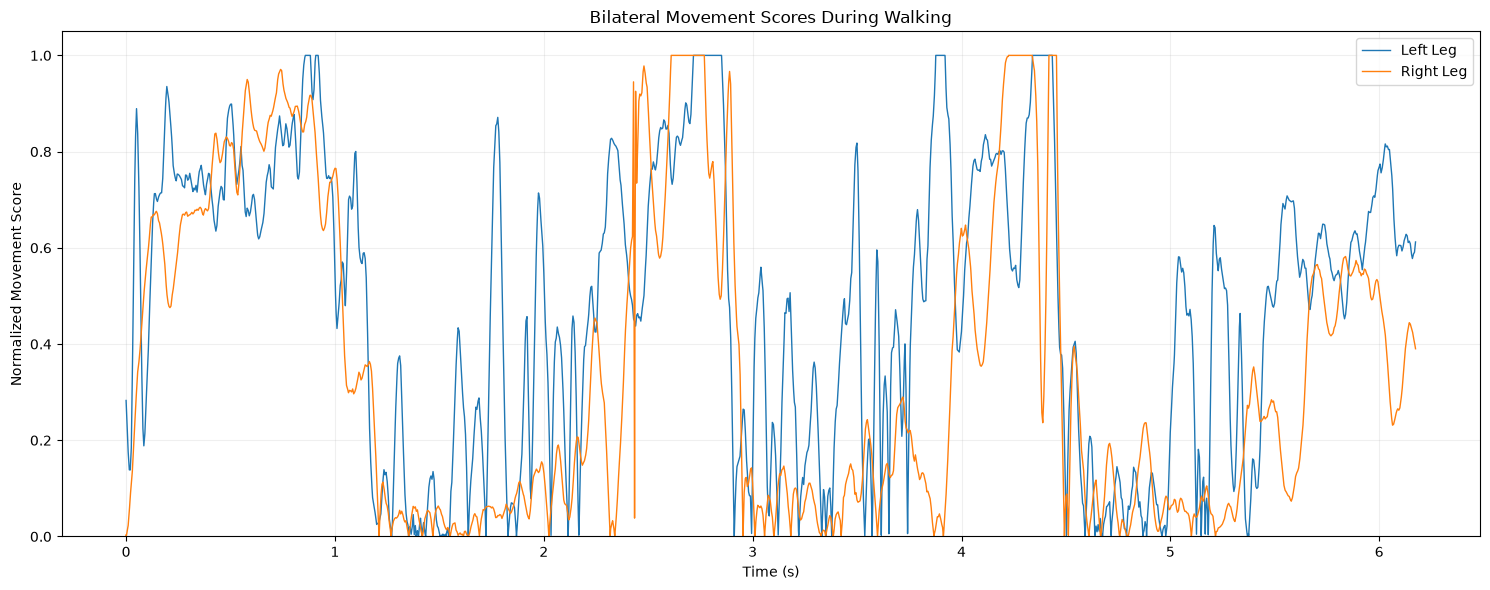

In [15]:
# Plot left and right movement scores
plt.figure(figsize=(15, 6))

plt.plot(
    walking_work[time_col],
    walking_work['MovementScore_L'],
    label='Left Leg',
    linewidth=1
)

plt.plot(
    walking_work[time_col],
    walking_work['MovementScore_R'],
    label='Right Leg',
    linewidth=1
)

plt.title('Bilateral Movement Scores During Walking')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Movement Score')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
# Quick check of the generated scores
walking_work[['MovementScore_L', 'MovementScore_R']].describe()

,MovementScore_L,MovementScore_R
count,12351.000000,12351.000000
mean,0.484245,0.357214
std,0.300215,0.325473
min,0.000040,0.000015
25%,0.190159,0.063643
50%,0.519919,0.241340
75%,0.738380,0.626511
max,1.000000,1.000000


### 8. Convert Movement Scores into Bilateral States

In [18]:
# Convert movement score to state
N_STATES = 10
def score_to_state(score, n_states = N_STATES):
    """
     Example with 10 states:
    0.00-0.10 -> S0
    0.10-0.20 -> S1
    ...
    0.90-1.00 -> S9
    """
    state = np.floor(score * n_states).astype(int)
    state = np.clip(state, 0, n_states - 1)
    return state

walking_work['State_L'] = score_to_state(walking_work['MovementScore_L'])
walking_work['State_R'] = score_to_state(walking_work['MovementScore_R'])

In [19]:
# Create the bilateral state column (L, R)
walking_work['BilateralState'] = (
    'L' + walking_work['State_L'].astype(str)
    + '_R'
    + walking_work['State_R'].astype(str)
)

In [20]:
walking_work[
    [
        time_col,
        'MovementScore_L',
        'State_L',
        'MovementScore_R',
        'State_R',
        'BilateralState'
    ]
].head(20)

,Time_s,MovementScore_L,State_L,MovementScore_R,State_R,BilateralState
0,0.0000,0.282736,2,0.003068,0,L2_R0
1,0.0005,0.277158,2,0.001648,0,L2_R0
2,0.0010,0.271565,2,0.000228,0,L2_R0
3,0.0015,0.265955,2,0.001191,0,L2_R0
4,0.0020,0.260329,2,0.002610,0,L2_R0
5,0.0025,0.254687,2,0.004028,0,L2_R0
6,0.0030,0.249029,2,0.005447,0,L2_R0
7,0.0035,0.243354,2,0.006864,0,L2_R0
8,0.0040,0.237663,2,0.008282,0,L2_R0
9,0.0045,0.231956,2,0.009699,0,L2_R0


In [21]:
# Inspect how frequently each state occurs
print("LEFT LEG STATE COUNTS")
print(walking_work['State_L'].value_counts().sort_index())

print("\nRIGHT LEG STATE COUNTS")
print(walking_work['State_R'].value_counts().sort_index())

LEFT LEG STATE COUNTS
State_L
0    1955
1    1220
2     789
3     756
4    1204
5    1440
6    1292
7    1705
8    1122
9     868
Name: count, dtype: int64

RIGHT LEG STATE COUNTS
State_R
0    4192
1    1608
2     959
3     747
4     695
5     910
6     819
7     509
8     806
9    1106
Name: count, dtype: int64


In [22]:
left_percent = (walking_work['State_L'].value_counts(normalize=True).sort_index() * 100)
right_percent = (walking_work['State_R'].value_counts(normalize=True).sort_index() * 100)

state_distribution = pd.DataFrame({
    'Left (%)': left_percent,
    'Right (%)': right_percent
}).fillna(0)

state_distribution

,Left (%),Right (%)
0,15.828678,33.940572
1,9.877743,13.019189
2,6.388147,7.764553
3,6.120962,6.048093
4,9.748199,5.627075
5,11.658975,7.367824
6,10.460691,6.631042
7,13.804550,4.121124
8,9.084285,6.525787
9,7.027771,8.954741


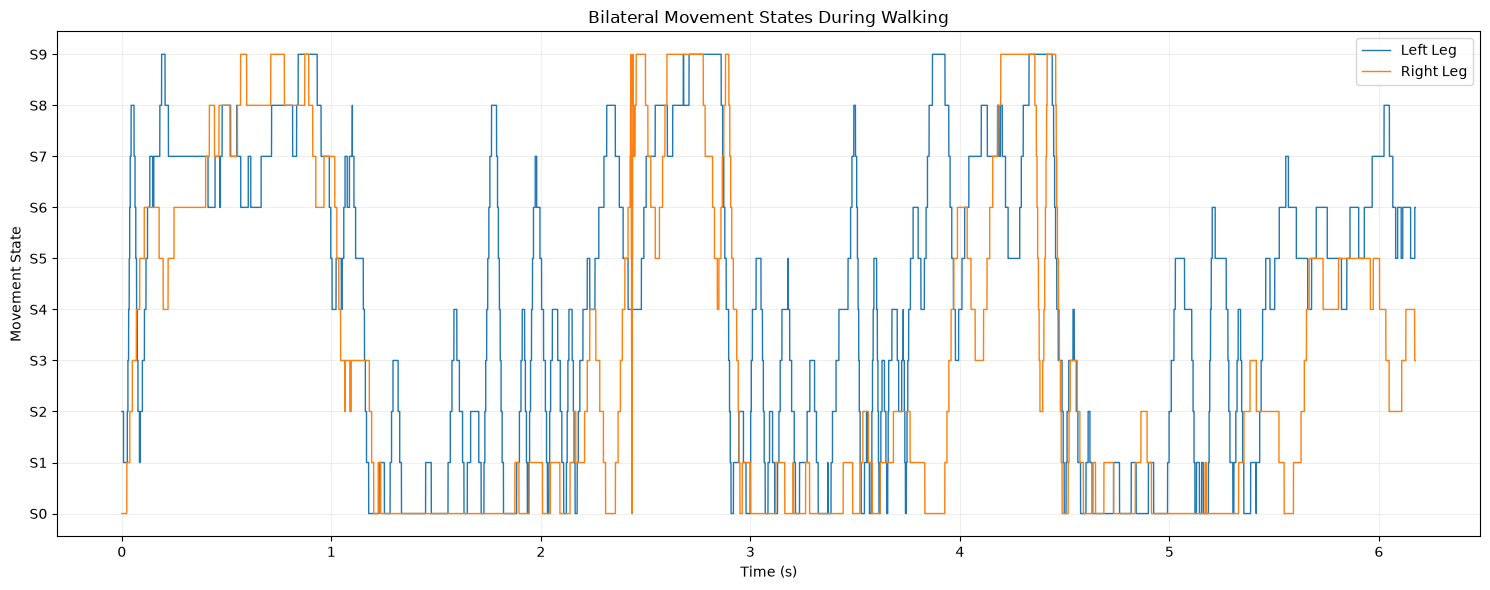

In [23]:
# Visualize the states
plt.figure(figsize=(15, 6))

plt.step(
    walking_work[time_col],
    walking_work['State_L'],
    where='post',
    label='Left Leg',
    linewidth=1
)

plt.step(
    walking_work[time_col],
    walking_work['State_R'],
    where='post',
    label='Right Leg',
    linewidth=1
)

plt.title('Bilateral Movement States During Walking')
plt.xlabel('Time (s)')
plt.ylabel('Movement State')
plt.yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 9. Visualize and Inspect Bilateral State Progression
Do these states actually behave sensibly over time?

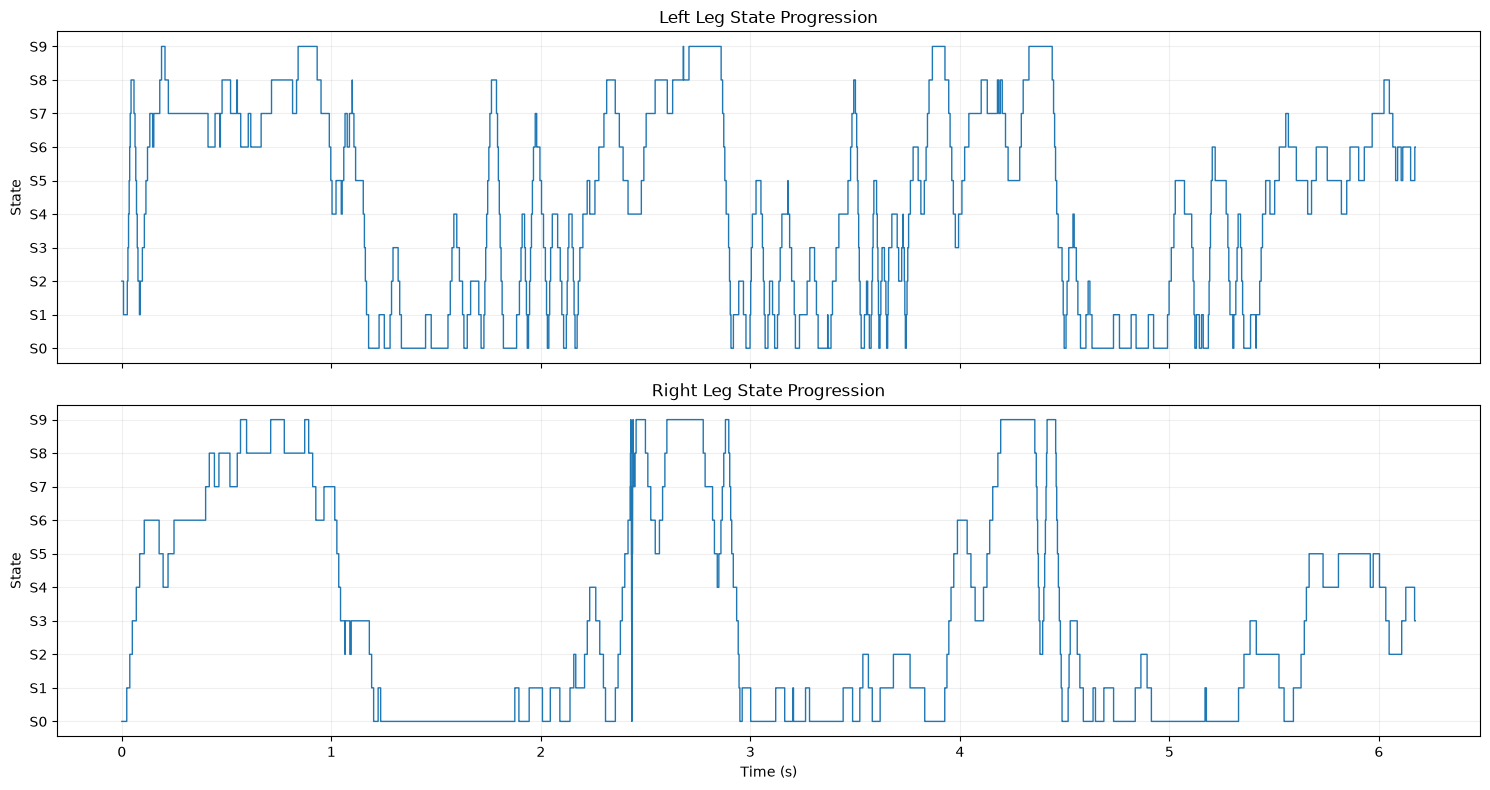

In [24]:
# Plot left and right states separately

fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True
)

axes[0].step(
    walking_work[time_col],
    walking_work['State_L'],
    where='post',
    linewidth=1
)
axes[0].set_title('Left Leg State Progression')
axes[0].set_ylabel('State')
axes[0].set_yticks(
    range(N_STATES),
    [f'S{i}' for i in range(N_STATES)]
)
axes[0].grid(alpha=0.2)

axes[1].step(
    walking_work[time_col],
    walking_work['State_R'],
    where='post',
    linewidth=1
)
axes[1].set_title('Right Leg State Progression')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('State')
axes[1].set_yticks(
    range(N_STATES),
    [f'S{i}' for i in range(N_STATES)]
)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

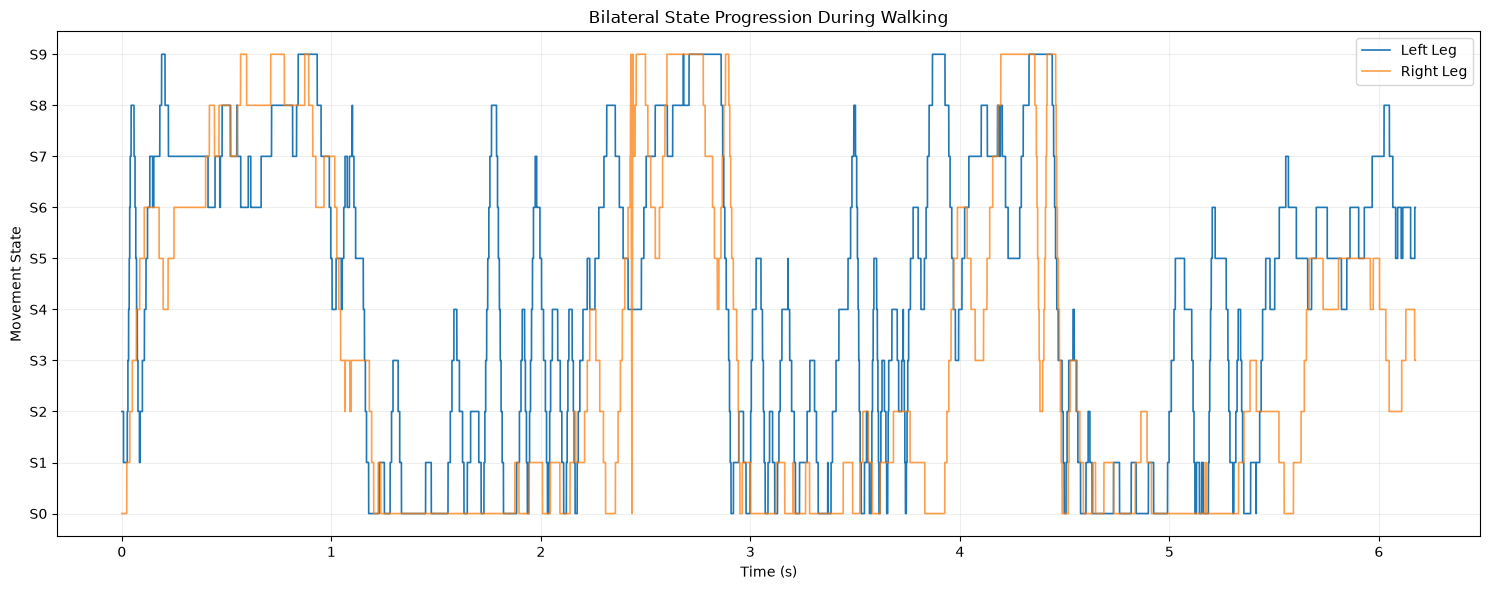

In [25]:
# Plot left and right together
plt.figure(figsize=(15, 6))

plt.step(
    walking_work[time_col],
    walking_work['State_L'],
    where='post',
    label='Left Leg',
    linewidth=1.2
)

plt.step(
    walking_work[time_col],
    walking_work['State_R'],
    where='post',
    label='Right Leg',
    linewidth=1.2,
    alpha=0.75
)

plt.title('Bilateral State Progression During Walking')
plt.xlabel('Time (s)')
plt.ylabel('Movement State')
plt.yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [26]:
# Create state-change columns
walking_work['StateChange_L'] = (
    walking_work['State_L']
    != walking_work['State_L'].shift(1)
)
walking_work['StateChange_R'] = (
    walking_work['State_R']
    != walking_work['State_R'].shift(1)
)
walking_work['BilateralChange'] = (
    walking_work['StateChange_L']
    | walking_work['StateChange_R']
)

# Extract only bilateral state changes
state_changes = walking_work.loc[
    walking_work['BilateralChange'],
    [
        time_col,
        'State_L',
        'State_R',
        'BilateralState'
    ]].copy()

state_changes.head(30)

,Time_s,State_L,State_R,BilateralState
0,0.0000,2,0,L2_R0
16,0.0080,1,0,L1_R0
47,0.0235,1,1,L1_R1
52,0.0260,2,1,L2_R1
58,0.0290,3,1,L3_R1
64,0.0320,4,1,L4_R1
70,0.0350,5,1,L5_R1
75,0.0375,6,1,L6_R1
76,0.0380,6,2,L6_R2
80,0.0400,7,2,L7_R2


In [27]:
# Check how many state changes occurred
print("Total samples:", len(walking_work))
print("Bilateral state changes:", len(state_changes))
print("Left state changes:", walking_work['StateChange_L'].sum())
print("Right state changes:", walking_work['StateChange_R'].sum())

Total samples: 12351
Bilateral state changes: 583
Left state changes: 385
Right state changes: 205


In [28]:
# See the most common bilateral states
bilateral_counts = (
    walking_work['BilateralState']
    .value_counts()
    .reset_index()
)
bilateral_counts.columns = [
    'Bilateral State',
    'Sample Count'
]

bilateral_counts.head(15)

,Bilateral State,Sample Count
0,L0_R0,1377
1,L1_R0,766
2,L2_R0,499
3,L7_R6,479
4,L0_R1,372
5,L8_R9,361
6,L4_R0,355
7,L3_R0,352
8,L5_R0,317
9,L9_R9,283


### 10. Analyze Bilateral State Transitions

In [29]:
walking_work['Prev_State_L'] = walking_work['State_L'].shift(1)
walking_work['Prev_State_R'] = walking_work['State_R'].shift(1)
walking_work['DeltaState_L'] = walking_work['State_L'] - walking_work['Prev_State_L']
walking_work['DeltaState_R'] = walking_work['State_R'] - walking_work['Prev_State_R']

transition_rows = walking_work.loc[
    (walking_work['DeltaState_L'] != 0) |
    (walking_work['DeltaState_R'] != 0),
    [
        time_col,
        'Prev_State_L', 'State_L',
        'Prev_State_R', 'State_R',
        'DeltaState_L', 'DeltaState_R',
        'BilateralState'
    ]
].dropna().copy()

transition_rows.head(20)

,Time_s,Prev_State_L,State_L,Prev_State_R,State_R,DeltaState_L,DeltaState_R,BilateralState
16,0.0080,2.0,1,0.0,0,-1.0,0.0,L1_R0
47,0.0235,1.0,1,0.0,1,0.0,1.0,L1_R1
52,0.0260,1.0,2,1.0,1,1.0,0.0,L2_R1
58,0.0290,2.0,3,1.0,1,1.0,0.0,L3_R1
64,0.0320,3.0,4,1.0,1,1.0,0.0,L4_R1
70,0.0350,4.0,5,1.0,1,1.0,0.0,L5_R1
75,0.0375,5.0,6,1.0,1,1.0,0.0,L6_R1
76,0.0380,6.0,6,1.0,2,0.0,1.0,L6_R2
80,0.0400,6.0,7,2.0,2,1.0,0.0,L7_R2
88,0.0440,7.0,8,2.0,2,1.0,0.0,L8_R2


In [30]:
print("Number of observed bilateral transitions:", len(transition_rows))
print("\nLeft state-change size:")
print(transition_rows['DeltaState_L'].value_counts().sort_index())
print("\nRight state-change size:")
print(transition_rows['DeltaState_R'].value_counts().sort_index())

Number of observed bilateral transitions: 582

Left state-change size:
DeltaState_L
-1.0    190
 0.0    198
 1.0    194
Name: count, dtype: int64

Right state-change size:
DeltaState_R
-1.0    101
 0.0    378
 1.0    102
 2.0      1
Name: count, dtype: int64


In [31]:
bilateral_state_counts = (
    walking_work['BilateralState']
    .value_counts()
    .rename_axis('BilateralState')
    .reset_index(name='Count')
)
bilateral_state_counts['Percentage'] = (
    100 * bilateral_state_counts['Count'] / len(walking_work)
)
bilateral_state_counts.head(20)

,BilateralState,Count,Percentage
0,L0_R0,1377,11.148895
1,L1_R0,766,6.201927
2,L2_R0,499,4.040159
3,L7_R6,479,3.878228
4,L0_R1,372,3.011902
5,L8_R9,361,2.922840
6,L4_R0,355,2.874261
7,L3_R0,352,2.849972
8,L5_R0,317,2.566594
9,L9_R9,283,2.291312


### 11. Prepare the Machine-Learning Dataset

In [32]:
label_source_cols = [
    'Thigh_L_Accel_X', 'Thigh_L_Accel_Y', 'Thigh_L_Accel_Z',
    'Thigh_R_Accel_X', 'Thigh_R_Accel_Y', 'Thigh_R_Accel_Z'
]
sensor_cols = emg_cols + imu_cols
feature_cols = [
    c for c in sensor_cols
    if c not in label_source_cols and c in walking_work.columns
]
print("Number of model features:", len(feature_cols))
print("\nExcluded label-source columns:")
print(label_source_cols)

Number of model features: 38

Excluded label-source columns:
['Thigh_L_Accel_X', 'Thigh_L_Accel_Y', 'Thigh_L_Accel_Z', 'Thigh_R_Accel_X', 'Thigh_R_Accel_Y', 'Thigh_R_Accel_Z']


In [33]:
X = walking_work[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
y = walking_work[['State_L', 'State_R']].copy()
X = X.fillna(X.median(numeric_only=True))
print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (12351, 38)
y shape: (12351, 2)


,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
0,-2.1386,0.4033,-17.1598,-3.3709,-5.4275,-0.1902,-2.9087,-3.6227,-17.4844,-0.7046,11.1875,1003.9,-157.7148,-210.8154,-24.3281,-11.7109,0.7275,292.4805,518.0664,804.1992,28.5156,-6.9961,-13.9062,-3.1660,22.4062,4.4492,976.5625,119.9951,-235.4736,-18.3438,4.5195,-11.9219,-281.9824,414.5508,878.9062,22.4844,1.6807,-1.5576
1,0.3029,-4.4798,-20.5170,-5.2020,-6.0378,-1.1058,-0.4672,-8.8110,-17.4312,-0.5538,11.0125,1004.4,-157.5073,-209.6069,-24.0219,-11.7094,0.8296,290.9424,517.7246,805.1270,28.2375,-6.9844,-13.8141,-3.2521,22.3188,4.4898,976.0742,118.7500,-234.1309,-18.3078,4.4965,-11.9438,-283.6670,414.6729,880.0781,22.6969,1.7061,-1.5552
2,2.1341,-10.5837,-22.6533,-6.7280,-5.4275,-2.0214,2.5848,-9.4214,-17.3781,-0.4029,10.8375,1004.9,-157.2998,-208.3984,-23.7156,-11.7078,0.9316,289.4043,517.3828,806.0547,27.9594,-6.9727,-13.7219,-3.3383,22.2313,4.5305,975.5859,117.5049,-232.7881,-18.2719,4.4734,-11.9656,-285.3516,414.7949,881.2500,22.9094,1.7314,-1.5527
3,4.2704,-17.2980,-22.6533,-5.8124,-3.5963,-2.3266,4.1107,-8.2006,-17.3250,-0.2521,10.6625,1005.4,-157.0923,-207.1899,-23.4094,-11.7062,1.0337,287.8662,517.0410,806.9824,27.6812,-6.9609,-13.6297,-3.4244,22.1437,4.5711,975.0977,116.2598,-231.4453,-18.2359,4.4504,-11.9875,-287.0361,414.9170,882.4219,23.1219,1.7568,-1.5503
4,7.3224,-22.7915,-21.7377,-5.5072,-0.2392,-2.3266,3.5004,-8.2006,-17.2719,-0.1013,10.4875,1005.9,-156.8848,-205.9814,-23.1031,-11.7047,1.1357,286.3281,516.6992,807.9102,27.4031,-6.9492,-13.5375,-3.5105,22.0562,4.6117,974.6094,115.0146,-230.1025,-18.2000,4.4273,-12.0094,-288.7207,415.0391,883.5938,23.3344,1.7822,-1.5479


In [34]:
TRAIN_RATIO = 0.80
split_index = int(len(X) * TRAIN_RATIO)
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()
time_train = walking_work[time_col].iloc[:split_index].copy()
time_test = walking_work[time_col].iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print(f"Training time: {time_train.iloc[0]:.3f} to {time_train.iloc[-1]:.3f} s")
print(f"Testing time:  {time_test.iloc[0]:.3f} to {time_test.iloc[-1]:.3f} s")

Training samples: 9880
Testing samples: 2471
Training time: 0.000 to 4.939 s
Testing time:  4.939 to 6.174 s


### 12. Train the Initial Bilateral State Classifier

In [35]:
state_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

state_model.fit(X_train, y_train)
y_pred = state_model.predict(X_test)
pred_L = y_pred[:, 0]
pred_R = y_pred[:, 1]
print("Model training complete.")

Model training complete.


### 13. Evaluate the State Classifier

In [36]:
accuracy_L = accuracy_score(y_test['State_L'], pred_L)
accuracy_R = accuracy_score(y_test['State_R'], pred_R)
print(f"Left state accuracy:  {accuracy_L:.3f}")
print(f"Right state accuracy: {accuracy_R:.3f}")

Left state accuracy:  0.196
Right state accuracy: 0.300


In [37]:
print("LEFT LEG CLASSIFICATION REPORT")
print(classification_report(y_test['State_L'], pred_L, zero_division=0))
print("\nRIGHT LEG CLASSIFICATION REPORT")
print(classification_report(y_test['State_R'], pred_R, zero_division=0))

LEFT LEG CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.28      0.74      0.41       265
           1       0.16      0.03      0.05       217
           2       0.00      0.00      0.00        82
           3       0.00      0.00      0.00        88
           4       0.25      0.26      0.26       291
           5       0.46      0.03      0.06       735
           6       0.34      0.02      0.04       571
           7       0.17      1.00      0.28       171
           8       0.00      0.00      0.00        51

    accuracy                           0.20      2471
   macro avg       0.19      0.23      0.12      2471
weighted avg       0.30      0.20      0.12      2471


RIGHT LEG CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       858
           1       0.03      0.07      0.04       187
           2       0.00      0.00      0.00       425
           3  

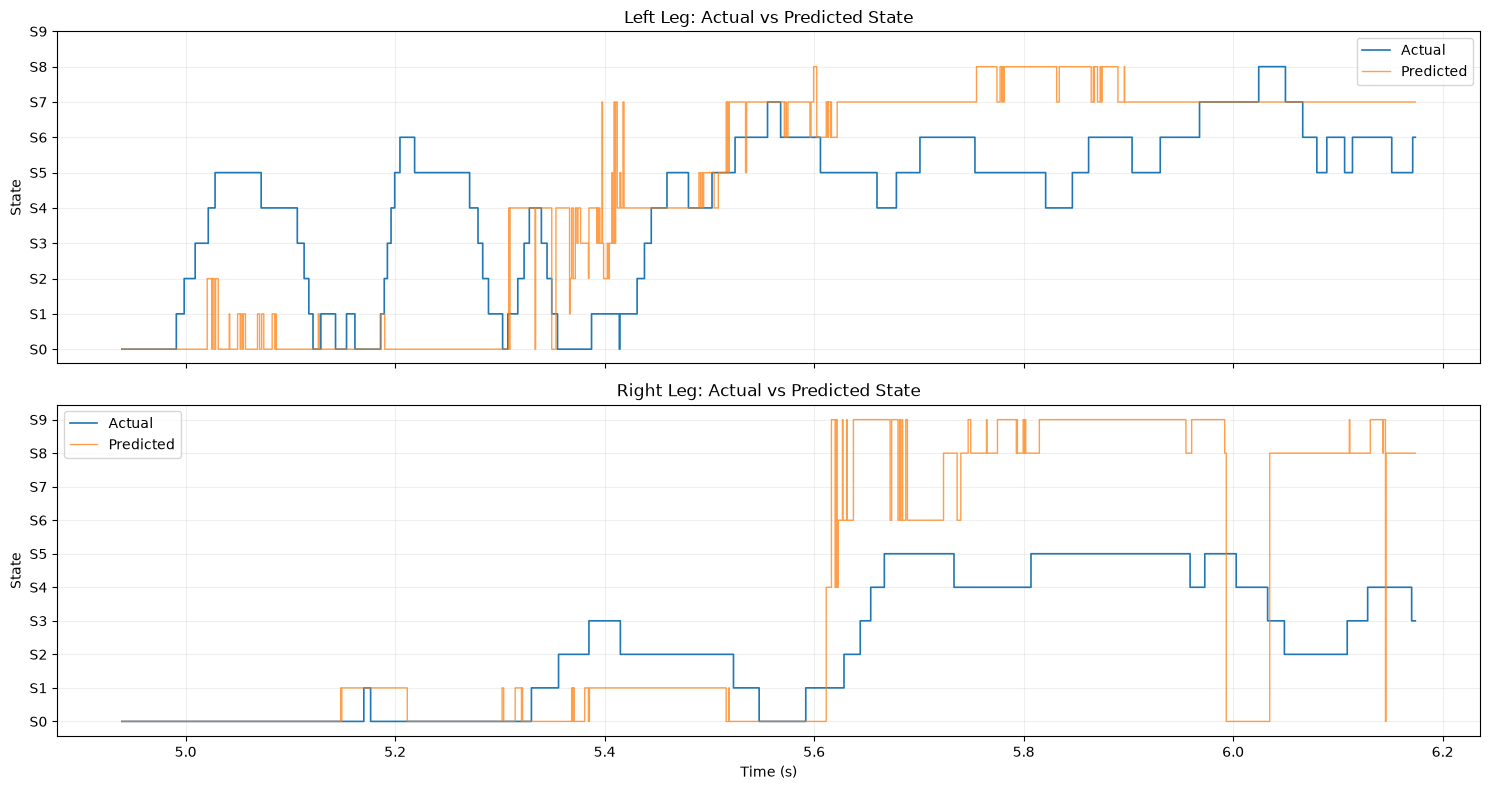

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].step(time_test, y_test['State_L'], where='post',
             label='Actual', linewidth=1.2)
axes[0].step(time_test, pred_L, where='post',
             label='Predicted', linewidth=1.0, alpha=0.75)
axes[0].set_title('Left Leg: Actual vs Predicted State')
axes[0].set_ylabel('State')
axes[0].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[0].legend()
axes[0].grid(alpha=0.2)
axes[1].step(time_test, y_test['State_R'], where='post',
             label='Actual', linewidth=1.2)
axes[1].step(time_test, pred_R, where='post',
             label='Predicted', linewidth=1.0, alpha=0.75)
axes[1].set_title('Right Leg: Actual vs Predicted State')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('State')
axes[1].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

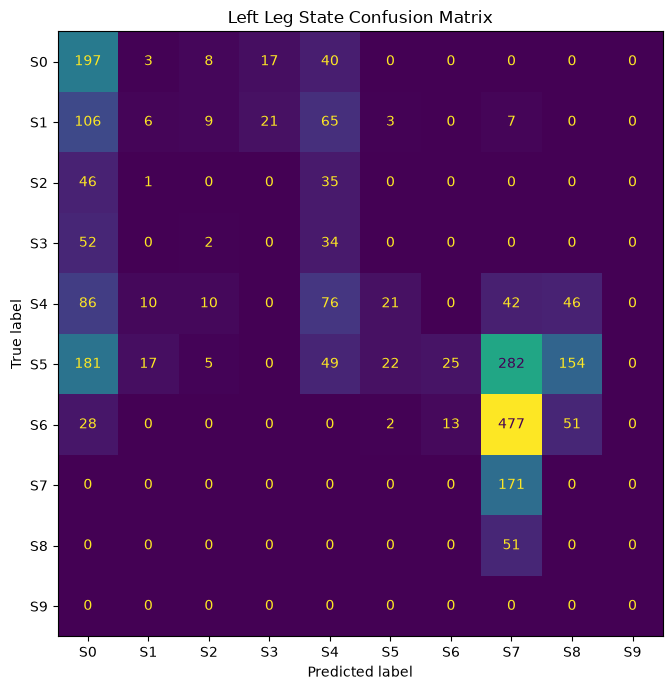

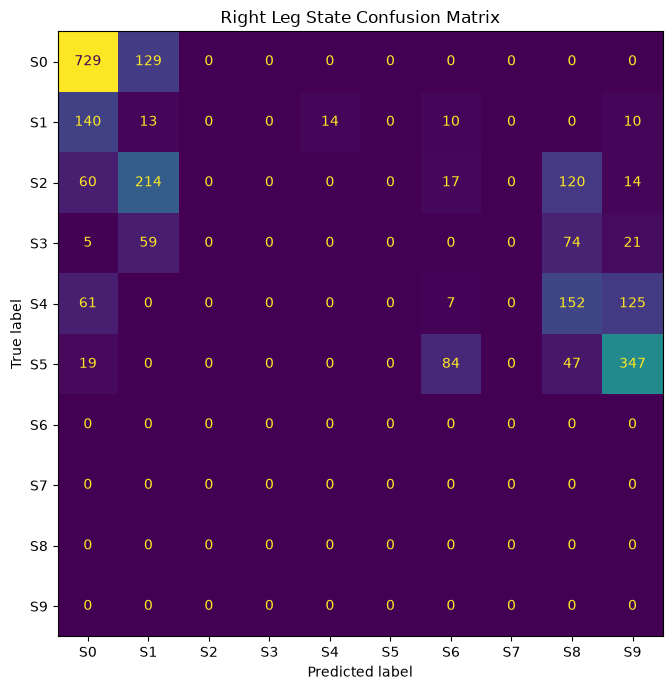

In [39]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test['State_L'], pred_L,
    labels=range(N_STATES),
    display_labels=[f'S{i}' for i in range(N_STATES)],
    ax=ax,
    colorbar=False
)
ax.set_title('Left Leg State Confusion Matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test['State_R'], pred_R,
    labels=range(N_STATES),
    display_labels=[f'S{i}' for i in range(N_STATES)],
    ax=ax,
    colorbar=False
)
ax.set_title('Right Leg State Confusion Matrix')
plt.tight_layout()
plt.show()

### 14. Bilateral Transition Validation and Fault Detection

In [40]:
MAX_STATE_JUMP = 7
test_results = pd.DataFrame({
    time_col: time_test.to_numpy(),
    'ActualState_L': y_test['State_L'].to_numpy(),
    'ActualState_R': y_test['State_R'].to_numpy(),
    'CandidateState_L': pred_L,
    'CandidateState_R': pred_R
})
accepted_L = []
accepted_R = []
fault_flags = []
prev_L = int(test_results['CandidateState_L'].iloc[0])
prev_R = int(test_results['CandidateState_R'].iloc[0])

for _, row in test_results.iterrows():
    cand_L = int(row['CandidateState_L'])
    cand_R = int(row['CandidateState_R'])
    jump_L = abs(cand_L - prev_L)
    jump_R = abs(cand_R - prev_R)
    fault = (jump_L > MAX_STATE_JUMP) or (jump_R > MAX_STATE_JUMP)
    if fault:
        accepted_L.append(prev_L)
        accepted_R.append(prev_R)
        fault_flags.append(True)
    else:
        prev_L = cand_L
        prev_R = cand_R
        accepted_L.append(prev_L)
        accepted_R.append(prev_R)
        fault_flags.append(False)

test_results['AcceptedState_L'] = accepted_L
test_results['AcceptedState_R'] = accepted_R
test_results['FaultFlag'] = fault_flags
print("Detected transition faults:", test_results['FaultFlag'].sum())
test_results.head(20)

Detected transition faults: 84


,Time_s,ActualState_L,ActualState_R,CandidateState_L,CandidateState_R,AcceptedState_L,AcceptedState_R,FaultFlag
0,4.9391,0,0,0,0,0,0,False
1,4.9396,0,0,0,0,0,0,False
2,4.9401,0,0,0,0,0,0,False
3,4.9406,0,0,0,0,0,0,False
4,4.9411,0,0,0,0,0,0,False
5,4.9416,0,0,0,0,0,0,False
6,4.9421,0,0,0,0,0,0,False
7,4.9426,0,0,0,0,0,0,False
8,4.9431,0,0,0,0,0,0,False
9,4.9436,0,0,0,0,0,0,False


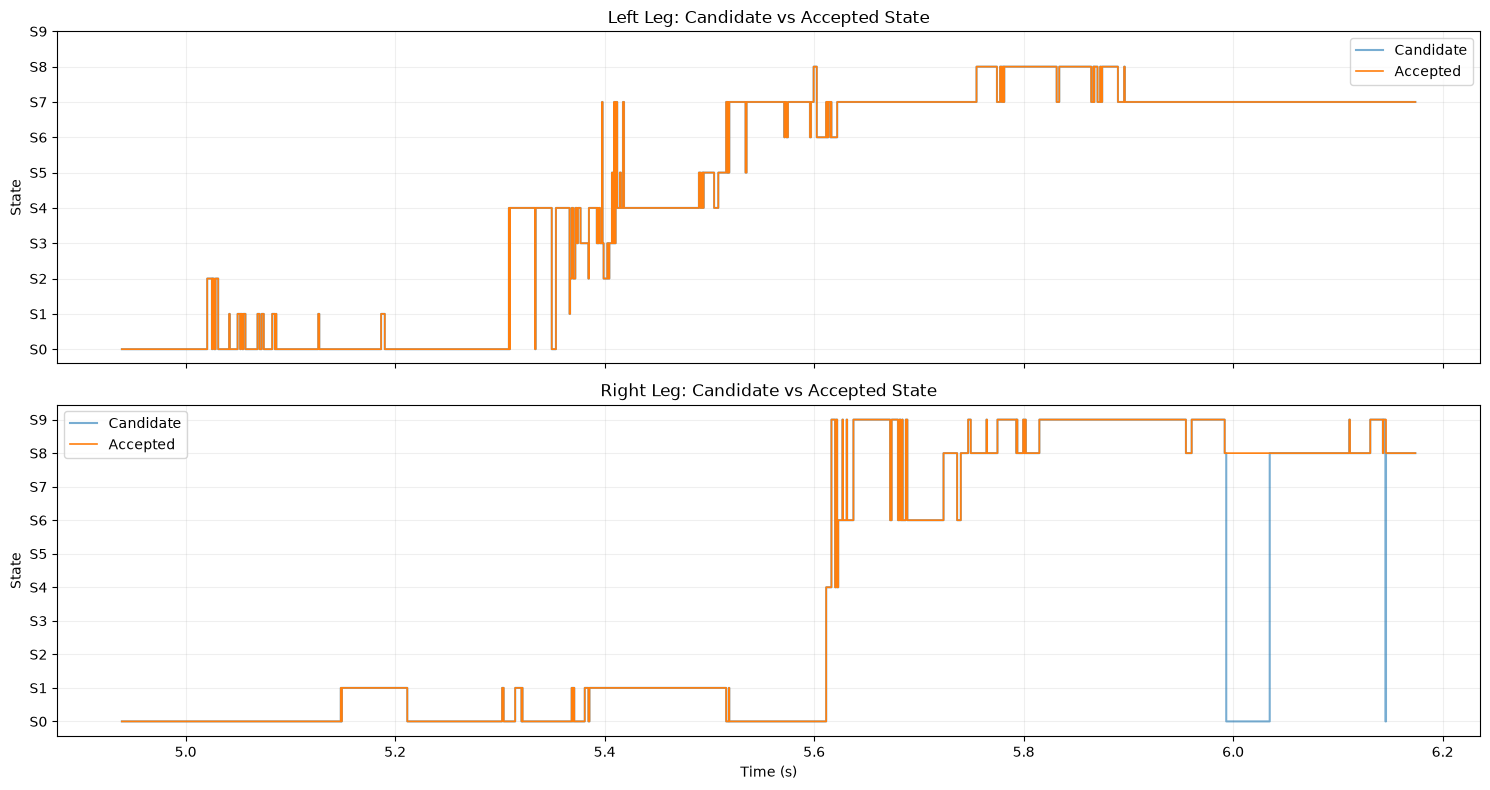

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].step(test_results[time_col], test_results['CandidateState_L'],
             where='post', label='Candidate', alpha=0.6)
axes[0].step(test_results[time_col], test_results['AcceptedState_L'],
             where='post', label='Accepted', linewidth=1.2)
axes[0].set_title('Left Leg: Candidate vs Accepted State')
axes[0].set_ylabel('State')
axes[0].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].step(test_results[time_col], test_results['CandidateState_R'],
             where='post', label='Candidate', alpha=0.6)
axes[1].step(test_results[time_col], test_results['AcceptedState_R'],
             where='post', label='Accepted', linewidth=1.2)
axes[1].set_title('Right Leg: Candidate vs Accepted State')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('State')
axes[1].set_yticks(range(N_STATES), [f'S{i}' for i in range(N_STATES)])
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 15. Motor-State Mapping

In [42]:
def state_to_motor_command(state):
    if N_STATES <= 1:
        return 0.0
    return state / (N_STATES - 1)

test_results['MotorCommand_L'] = (
    test_results['AcceptedState_L'].apply(state_to_motor_command)
)
test_results['MotorCommand_R'] = (
    test_results['AcceptedState_R'].apply(state_to_motor_command)
)
test_results[
    [
        time_col,
        'AcceptedState_L', 'MotorCommand_L',
        'AcceptedState_R', 'MotorCommand_R',
        'FaultFlag'
    ]
].head(20)

,Time_s,AcceptedState_L,MotorCommand_L,AcceptedState_R,MotorCommand_R,FaultFlag
0,4.9391,0,0.0,0,0.0,False
1,4.9396,0,0.0,0,0.0,False
2,4.9401,0,0.0,0,0.0,False
3,4.9406,0,0.0,0,0.0,False
4,4.9411,0,0.0,0,0.0,False
5,4.9416,0,0.0,0,0.0,False
6,4.9421,0,0.0,0,0.0,False
7,4.9426,0,0.0,0,0.0,False
8,4.9431,0,0.0,0,0.0,False
9,4.9436,0,0.0,0,0.0,False


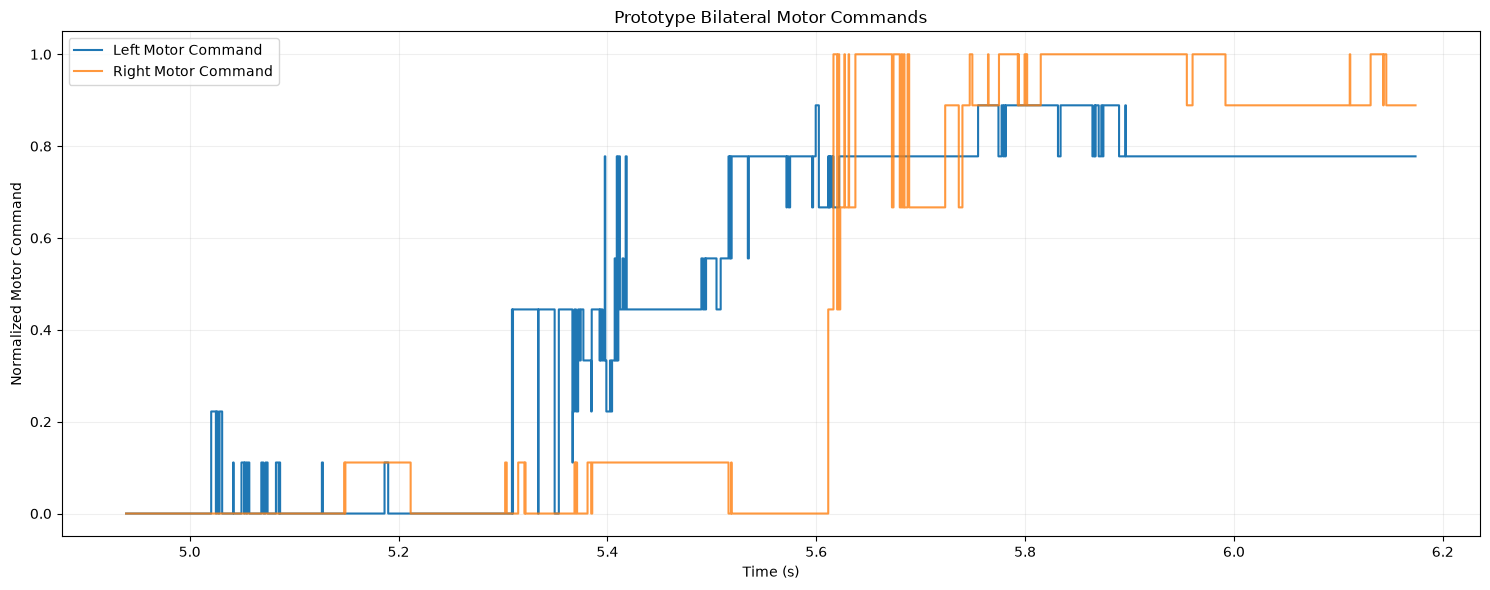

In [43]:
plt.figure(figsize=(15, 6))
plt.step(test_results[time_col], test_results['MotorCommand_L'],
         where='post', label='Left Motor Command')
plt.step(test_results[time_col], test_results['MotorCommand_R'],
         where='post', label='Right Motor Command', alpha=0.8)
plt.title('Prototype Bilateral Motor Commands')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Motor Command')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 16. Feature Importance

In [44]:
feature_importance = pd.Series(
    state_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance.head(15)

Shank_R_Gyro_Z     0.050428
Foot_L_Gyro_Y      0.045311
Thigh_R_Gyro_Y     0.045260
Foot_L_Gyro_Z      0.041869
Shank_L_Gyro_Z     0.038758
Foot_L_Gyro_X      0.038324
Foot_R_Gyro_Y      0.037850
Thigh_R_Gyro_Z     0.036604
Thigh_L_Gyro_Z     0.036012
Thigh_R_Gyro_X     0.035662
Shank_R_Gyro_Y     0.035639
Shank_R_Accel_Z    0.035350
Foot_R_Gyro_Z      0.033510
Shank_R_Accel_Y    0.033169
Foot_R_Gyro_X      0.032989
dtype: float64

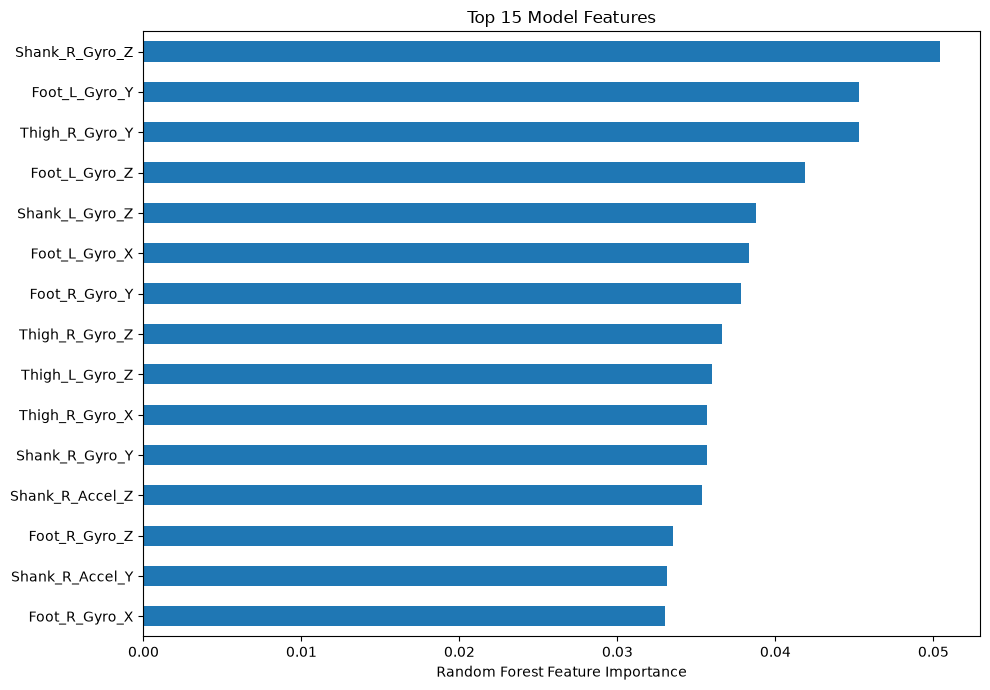

In [45]:
top_n = 15
plt.figure(figsize=(10, 7))
feature_importance.head(top_n).sort_values().plot(kind='barh')
plt.title(f'Top {top_n} Model Features')
plt.xlabel('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### 17. Export Results

In [46]:
output_file = 'bilateral_state_results.csv'

test_results.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: bilateral_state_results.csv
